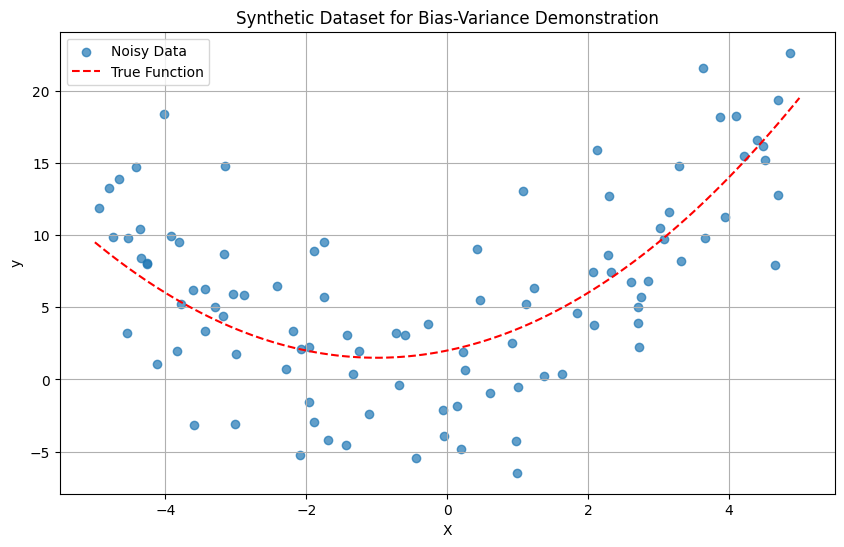

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# 1. Generate a synthetic dataset
np.random.seed(42)
X = np.random.rand(100, 1) * 10 - 5 # 100 samples between -5 and 5
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1) * 5 # Quadratic relationship with noise

# Create a perfect test set for plotting the true function
X_test_plot = np.linspace(-5, 5, 100).reshape(-1, 1)
y_true = 0.5 * X_test_plot**2 + X_test_plot + 2

plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Noisy Data', alpha=0.7)
plt.plot(X_test_plot, y_true, color='red', label='True Function', linestyle='--')
plt.title('Synthetic Dataset for Bias-Variance Demonstration')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()


The plot above shows our synthetic dataset. The red dashed line represents the true underlying quadratic function, and the blue dots are the noisy data points we'll use for training. Now, let's train two models with different complexities.

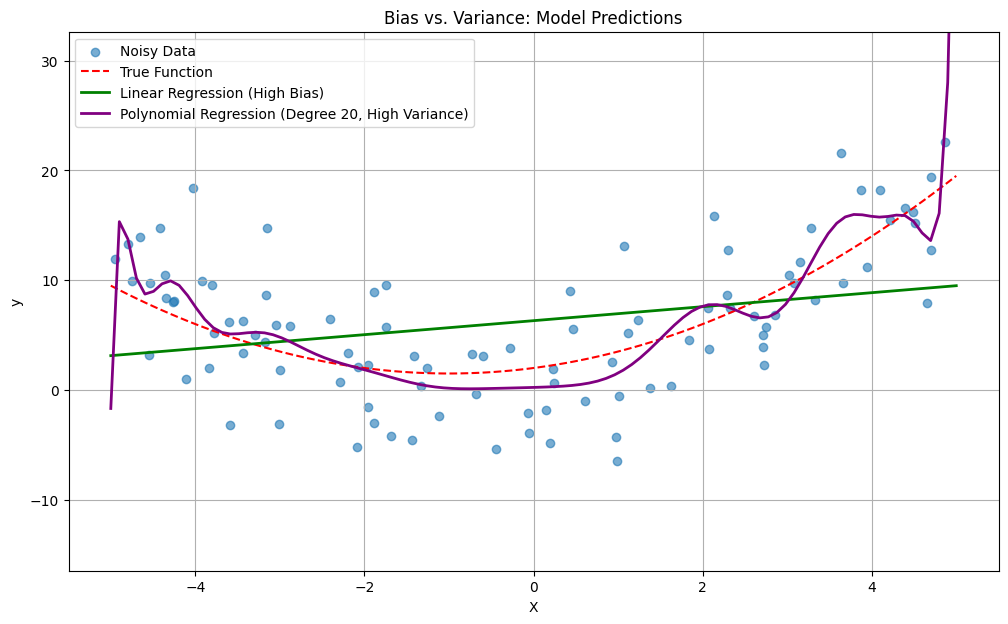

MSE for Linear Regression (High Bias): 15.57
MSE for Polynomial Regression (High Variance): 22.01


In [2]:
# 2. Define and train models with different complexities

# Model 1: High Bias (Simple Model - Linear Regression)
# This model is too simple to capture the quadratic relationship
model_linear = LinearRegression()
model_linear.fit(X, y)
y_pred_linear = model_linear.predict(X_test_plot)

# Model 2: Low Bias, High Variance (Complex Model - High-degree Polynomial Regression)
# This model is too complex and will likely overfit the noise
degree = 20 # A very high degree to demonstrate overfitting
model_polynomial = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model_polynomial.fit(X, y)
y_pred_polynomial = model_polynomial.predict(X_test_plot)

# 3. Visualize the models' predictions
plt.figure(figsize=(12, 7))

# Plot original data and true function
plt.scatter(X, y, label='Noisy Data', alpha=0.6)
plt.plot(X_test_plot, y_true, color='red', linestyle='--', label='True Function')

# Plot Linear Regression (High Bias)
plt.plot(X_test_plot, y_pred_linear, color='green', label='Linear Regression (High Bias)', linewidth=2)

# Plot Polynomial Regression (High Variance)
plt.plot(X_test_plot, y_pred_polynomial, color='purple', label=f'Polynomial Regression (Degree {degree}, High Variance)', linewidth=2)

plt.title('Bias vs. Variance: Model Predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.ylim(y.min() - 10, y.max() + 10) # Adjust y-limits for better visualization
plt.legend()
plt.grid(True)
plt.show()

print(f"MSE for Linear Regression (High Bias): {mean_squared_error(y_true, y_pred_linear):.2f}")
print(f"MSE for Polynomial Regression (High Variance): {mean_squared_error(y_true, y_pred_polynomial):.2f}")


### Explanation:

**Bias (Underfitting)**: The green line (Linear Regression) represents a high-bias model. It is too simple and cannot capture the underlying quadratic relationship of the data, consistently missing the true function (red dashed line). It underfits the data, leading to a high error on both training and unseen data because of its strong, incorrect assumptions about the data's form.

**Variance (Overfitting)**: The purple line (Polynomial Regression of degree 20) represents a high-variance model. It tries to fit every single data point, including the noise. While it might perform well on the training data, it wiggles excessively and deviates significantly from the true function, especially in regions where there are no data points. This means it will perform poorly on new, unseen data, as it's too sensitive to the specific training samples.

**The Ideal (Bias-Variance Trade-off)**: Ideally, we want a model that balances bias and variance. In this case, a polynomial regression of degree 2 (matching the true function) would achieve a good balance, having low bias (capturing the true relationship) and low variance (not being overly sensitive to noise). We can demonstrate this by training a `degree=2` polynomial model.

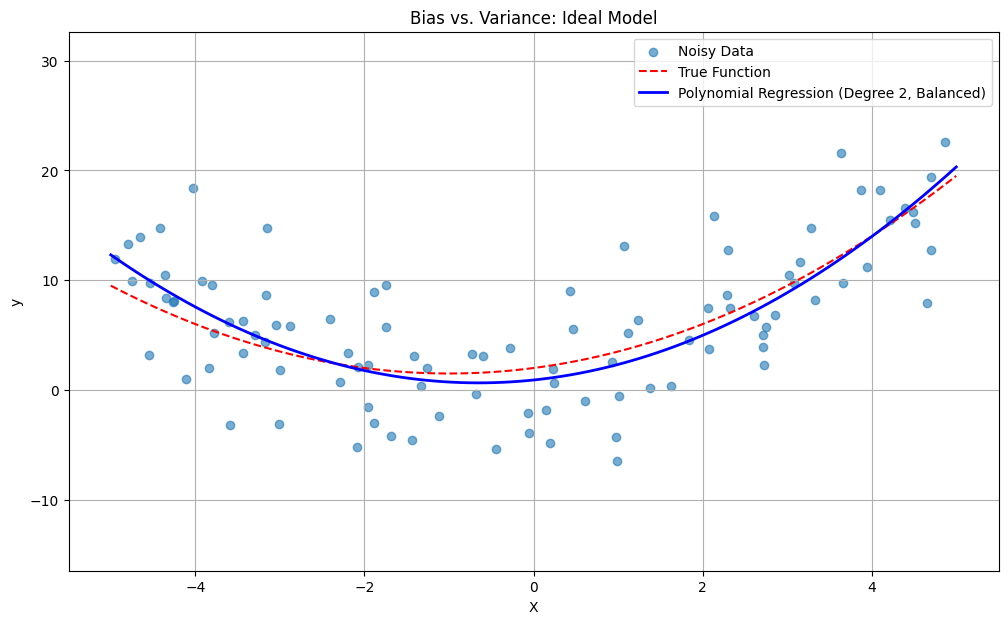

MSE for Ideal Polynomial Regression (Degree 2): 1.13


In [3]:
# 4. Demonstrate the Ideal (Balanced) Model
degree_ideal = 2 # Correct degree for the true function
model_ideal = make_pipeline(PolynomialFeatures(degree_ideal), LinearRegression())
model_ideal.fit(X, y)
y_pred_ideal = model_ideal.predict(X_test_plot)

plt.figure(figsize=(12, 7))

# Plot original data and true function
plt.scatter(X, y, label='Noisy Data', alpha=0.6)
plt.plot(X_test_plot, y_true, color='red', linestyle='--', label='True Function')

# Plot Ideal Polynomial Regression (Balanced Bias-Variance)
plt.plot(X_test_plot, y_pred_ideal, color='blue', label=f'Polynomial Regression (Degree {degree_ideal}, Balanced)', linewidth=2)

plt.title('Bias vs. Variance: Ideal Model')
plt.xlabel('X')
plt.ylabel('y')
plt.ylim(y.min() - 10, y.max() + 10) # Adjust y-limits for better visualization
plt.legend()
plt.grid(True)
plt.show()

print(f"MSE for Ideal Polynomial Regression (Degree {degree_ideal}): {mean_squared_error(y_true, y_pred_ideal):.2f}")


The blue line now shows a model that correctly identifies the underlying quadratic trend without being overly influenced by the noise, demonstrating a good balance between bias and variance. It has low bias because it captures the true function's shape and relatively low variance because it doesn't try to fit every noisy point perfectly.